Estimador Chi Cuadrado:

Ref. datos: archivo 'telecom-customer-churn.tab'.
Estos son datos reales de una empresa de telecomunicaciones referidos a
la "pérdida" (variable "churn") de clientes.

El departamento de MKT de la telco está interesado en reconocer qué
variables categóricas de este dataset están relacionadas o no con la
variable "churn".

Mediante la Prueba de Hipótesis determinamos qué variables
categóricas del dataset están relacionadas o no con churn (también categórica),
indicando el valor de chi cuadrado y de p en cada caso. Utilizaremos una significancia del 5%,
𝛼=0.05, para determinar si hay o no relación.

En los casos que sí haya relación se presentará:
la Tabla de Contingencia entre la variable en cuestión y churn
Gráfico para análisis



Nota: los valores de la columna SeniorCitizen no usaremos.


---



BIBLIOTECAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°2 Chi Cuadrado/telecom-customer-churn.tab', sep = '\t')
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,7590-VHVEG
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,5575-GNVDE
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3668-QPYBK
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7795-CFOCW
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,9237-HQITU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,6840-RESVB
7039,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,2234-XADUH
7040,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,4801-JZAZL
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,8361-LTMKD


En este caso particular debemos analizar si hay relación o no entre la pérdida de clientes (Churn) con el resto de las variables del set de datos.

Como mencionamos, los valores de la columna 'SeniorCitizen' no se van a usar, con lo cual, procederemos a eliminarla. Al igual que las columnas 'tenure', 'MonthlyCharges', 'TotalCharges', 'customerID', al ser variables numéricas también procedemos a eliminarlas ya que estamos buscando la relación existente entre variables categóricas respecto de 'Churn'. De esta manera, podemos disminuir problemas como la "Maldición de la Dimensionalidad".

In [ ]:
df.drop(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'customerID'], axis = 1, inplace = True)
df.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


PLANTEO DE HIPÓTESIS

Lo que se busca mostrar es si hay alguna relación ó influencia entre la pérdida de clientes de una empresa de telecomunicaciones,  y las diferentes variables categóricas.
Entonces las hipótesis planteadas son:

    

*   H1 : "La variable categórica ... influye en la pérdida de clientes ."
  (hipótesis alternativa)


*   Ho : "La variable categórica ...  no influye en la pérdida de clientes"   (hipótesis nula)



Ahora se procede a determinar si una variable explicativa  xi  guarda o no relación con la variable target  y (que para este caso es 'Churn').
Para este paso creo una lista de las variables categóricas a comparar con 'Churn'

Cuando hagamos el cálculo de nuestro estimador (Chi Cuadrado) junto con la probabilidad, no se utilizará la libreria "from scipy.stats import chisquare" ya que esta función compara frecuencias observadas contra esperadas en una sola variable (no entre dos categóricas).

En cambio, para este problema que estamos trabajando, debemos comparar dos variables categóricas, por ejemplo gender vs Churn. Para ello, debemos usar la función "chi2_contingency() de scipy.stats", que se aplica sobre tablas de contingencia (pd.crosstab).

In [ ]:
# Lista
categorical_columns = [col for col in df.columns if col != 'Churn']

Ahora se evalúa el valor Chi-Cuadrado junto con la probabilidad para cada variable categórica respecto a Churn:

In [ ]:
resultados = []

for col in categorical_columns:


    tabla = pd.crosstab(df[col], df['Churn'])                       # Creo la tabla de contingencia
    chi2, p, dof, expected = chi2_contingency(tabla)                # Función para calcular el estimador con la probabilidad.    ('dof' es el grado de libertad y 'expected' las frecuencias esperadas)
    resultados.append({'Variable': col, 'Chi2': chi2, 'p-value': p})        # Almaceno los resultados

resultados_df = pd.DataFrame(resultados)                                     # Guardo los resultados en un Dataframe

# Interpreto el resultado basado en el p-valor, considerando un nivel de significancia alfa de 0.05
resultados_df['Relacion'] = resultados_df['p-value'].apply(lambda p: 'Sí' if p < 0.05 else 'No')

print(resultados_df)

            Variable         Chi2        p-value Relacion
0             gender     0.484083   4.865787e-01       No
1            Partner   158.733382   2.139911e-36       Sí
2         Dependents   189.129249   4.924922e-43       Sí
3       PhoneService     0.915033   3.387825e-01       No
4      MultipleLines    11.330441   3.464383e-03       Sí
5    InternetService   732.309590  9.571788e-160       Sí
6     OnlineSecurity   849.998968  2.661150e-185       Sí
7       OnlineBackup   601.812790  2.079759e-131       Sí
8   DeviceProtection   558.419369  5.505219e-122       Sí
9        TechSupport   828.197068  1.443084e-180       Sí
10       StreamingTV   374.203943   5.528994e-82       Sí
11   StreamingMovies   375.661479   2.667757e-82       Sí
12          Contract  1184.596572  5.863038e-258       Sí
13  PaperlessBilling   258.277649   4.073355e-58       Sí
14     PaymentMethod   648.142327  3.682355e-140       Sí


Como podemos visualizar, la probabilidad en 'gender' y 'PhoneService' es mayor al nivel de significancia de 0.05.Con esto queremos decir que la probabilidad de esas dos variables están en 'genero' -> p = 0.48 y 'Servicio de telefonia' -> p = 0.34, con lo cual no podemos rechazar la hipótesis nula para ambos casos, ya que hay probabilidad del 48% y del 34% de que se cumpla. Entonces estamos diciendo que no podemos asegurar de que hay relación entre el genero y el servicio de telefonia con respecto a la pérdida de clientes.



---



Entoces pasando en claro, si el p-value es menor que  (α = 0.05), se rechaza la hipótesis nula (H0) ya que es muy baja la probabilidad de que esta ocurra. Con lo cual se concluye que sí hay una relación estadísticamente significativa.
Ahora si el p-value es mayor o igual que el nivel de significancia (0.05), no se rechaza la hipótesis nula (H0) y se concluye que 'No' hay evidencia de una relación estadísticamente significativa, es decir, no hay suficientes prueba para afirmar que hay o no relación.

Conclusión: Como p= 0.48 para 'gender', p= 0.34 para 'Phoneservice', y ambas son mayor que  α = 0.05  entonces no podemos rechazar la Hipótesis Nula y afirmamos que no existe relación o no influye  el género y el servicio de telefonía en la pérdida de cliente para la empresa.



---



Ahora para el resto de las variables que si tienen relación significativa (p < 0.05, rechazando H0), visualizamos la Tabla de Contingencia y gráfico entre la variable en cuestión y la variable objetivo 'Churn':

*Relación 'InternetService' y 'Churn'*

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113

 



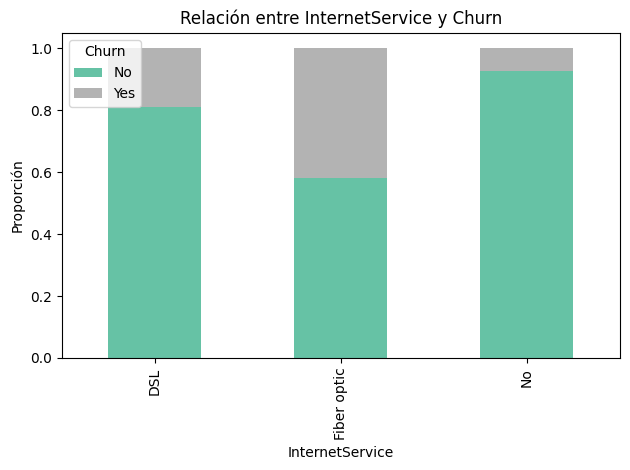

In [ ]:
# Tabla de contingencia
tabla = pd.crosstab(df['InternetService'], df['Churn'])
print(tabla)
print('\n \n')

# Gráfico de barras
tabla_norm = tabla.div(tabla.sum(1), axis=0)

tabla_norm.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre InternetService y Churn')
plt.ylabel('Proporción')
plt.xlabel('InternetService')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

*Relación 'Partner' y 'Churn'*

Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669

 



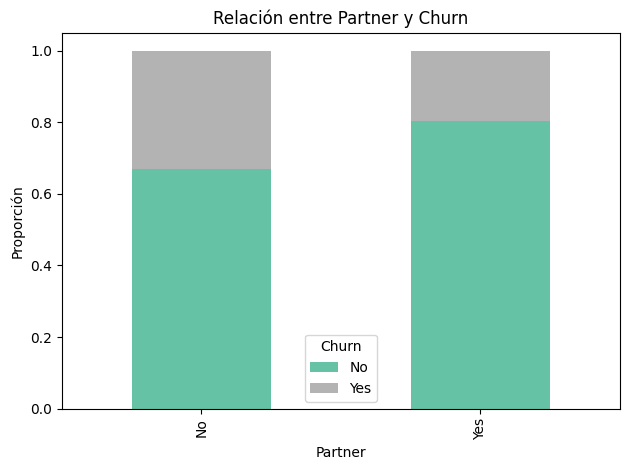

In [ ]:
# Tabla de contingencia
tabla2 = pd.crosstab(df['Partner'], df['Churn'])
print(tabla2)
print('\n \n')

# Gráfico de barras
tabla_norm2 = tabla2.div(tabla2.sum(1), axis=0)

tabla_norm2.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre Partner y Churn')
plt.ylabel('Proporción')
plt.xlabel('Partner')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

*Relación 'Dependents' y 'Churn'*

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326

 



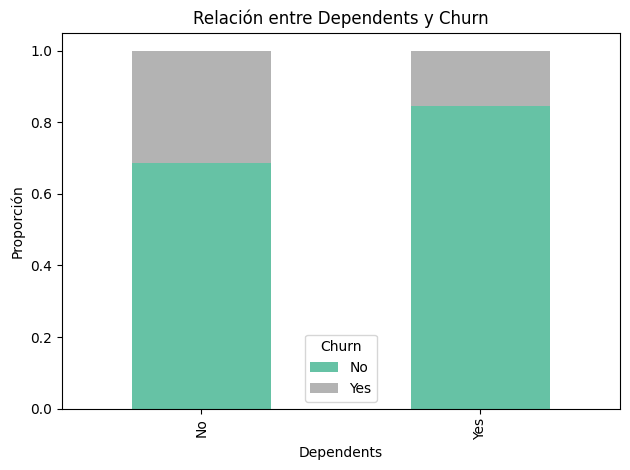

In [ ]:
# Tabla de contingencia
tabla3 = pd.crosstab(df['Dependents'], df['Churn'])
print(tabla3)
print('\n \n')

# Gráfico de barras
tabla_norm3 = tabla3.div(tabla3.sum(1), axis=0)

tabla_norm3.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre Dependents y Churn')
plt.ylabel('Proporción')
plt.xlabel('Dependents')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'MultipleLines' y 'Churn'

Churn               No  Yes
MultipleLines              
No                2541  849
No phone service   512  170
Yes               2121  850

 



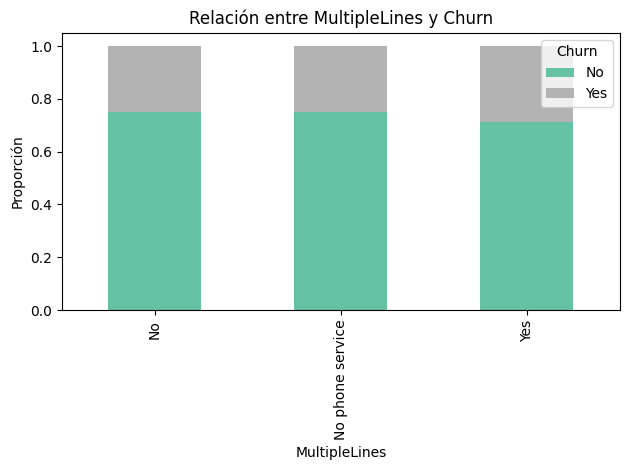

In [ ]:
# Tabla de contingencia
tabla4 = pd.crosstab(df['MultipleLines'], df['Churn'])
print(tabla4)
print('\n \n')

# Gráfico de barras
tabla_norm4 = tabla4.div(tabla4.sum(1), axis=0)

tabla_norm4.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre MultipleLines y Churn')
plt.ylabel('Proporción')
plt.xlabel('MultipleLines')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'OnlineSecurity' y 'Churn'

Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295

 



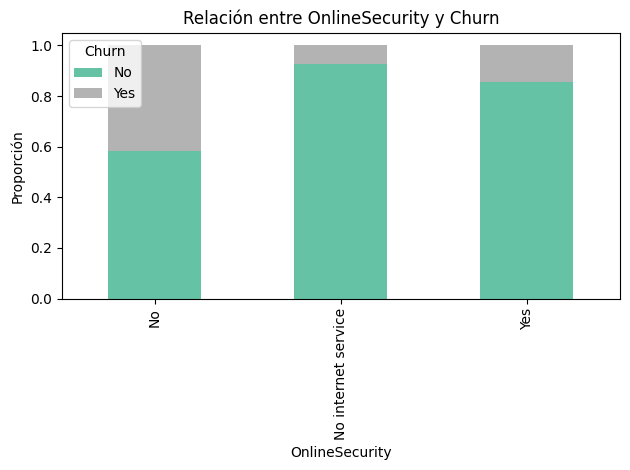

In [ ]:
# Tabla de contingencia
tabla5 = pd.crosstab(df['OnlineSecurity'], df['Churn'])
print(tabla5)
print('\n \n')

# Gráfico de barras
tabla_norm5 = tabla5.div(tabla5.sum(1), axis=0)

tabla_norm5.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre OnlineSecurity y Churn')
plt.ylabel('Proporción')
plt.xlabel('OnlineSecurity')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'OnlineBackup' y 'Churn'

Churn                  No   Yes
OnlineBackup                   
No                   1855  1233
No internet service  1413   113
Yes                  1906   523

 



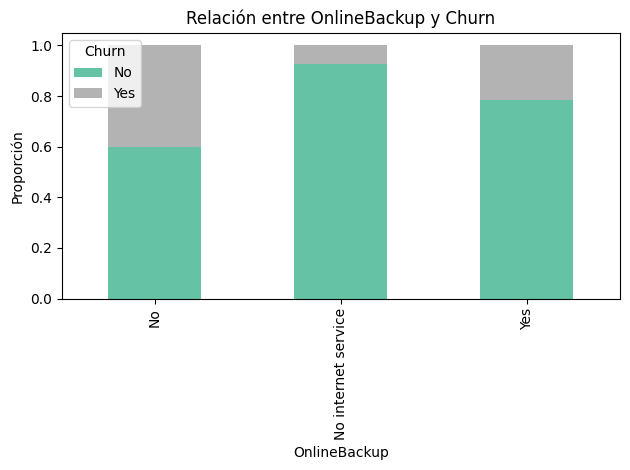

In [ ]:
# Tabla de contingencia
tabla6 = pd.crosstab(df['OnlineBackup'], df['Churn'])
print(tabla6)
print('\n \n')

# Gráfico de barras
tabla_norm6 = tabla6.div(tabla6.sum(1), axis=0)

tabla_norm6.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre OnlineBackup y Churn')
plt.ylabel('Proporción')
plt.xlabel('OnlineBackup')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'DeviceProtection' y 'Churn'

Churn                  No   Yes
DeviceProtection               
No                   1884  1211
No internet service  1413   113
Yes                  1877   545

 



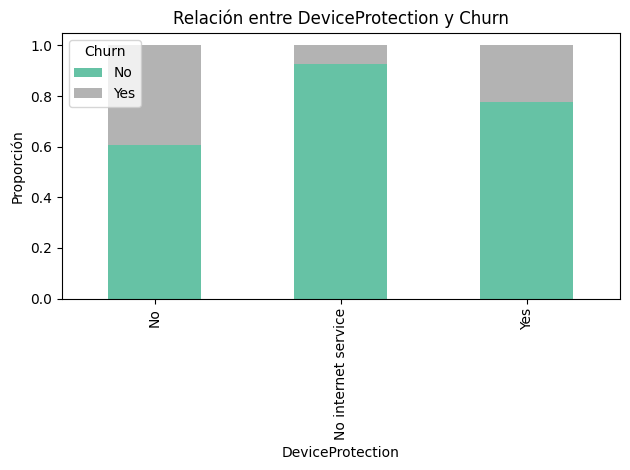

In [ ]:
# Tabla de contingencia
tabla7 = pd.crosstab(df['DeviceProtection'], df['Churn'])
print(tabla7)
print('\n \n')

# Gráfico de barras
tabla_norm7= tabla7.div(tabla7.sum(1), axis=0)

tabla_norm7.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre DeviceProtection y Churn')
plt.ylabel('Proporción')
plt.xlabel('DeviceProtection')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'TechSupport' y 'Churn'

Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310

 



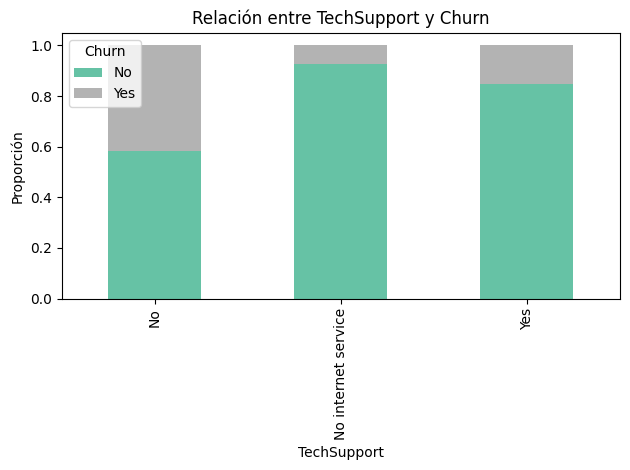

In [ ]:
# Tabla de contingencia
tabla8 = pd.crosstab(df['TechSupport'], df['Churn'])
print(tabla8)
print('\n \n')

# Gráfico de barras
tabla_norm8= tabla8.div(tabla8.sum(1), axis=0)

tabla_norm8.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre TechSupport y Churn')
plt.ylabel('Proporción')
plt.xlabel('TechSupport')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'StreamingTV' y 'Churn'

Churn                  No  Yes
StreamingTV                   
No                   1868  942
No internet service  1413  113
Yes                  1893  814

 



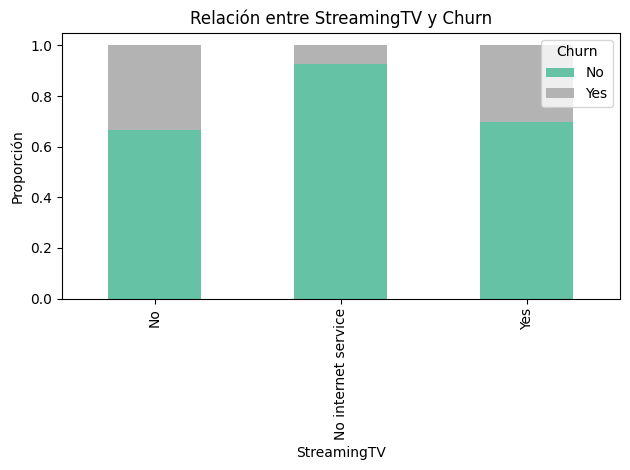

In [ ]:
# Tabla de contingencia
tabla9 = pd.crosstab(df['StreamingTV'], df['Churn'])
print(tabla9)
print('\n \n')

# Gráfico de barras
tabla_norm9= tabla9.div(tabla9.sum(1), axis=0)

tabla_norm9.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre StreamingTV y Churn')
plt.ylabel('Proporción')
plt.xlabel('StreamingTV')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'StreamingMovies' y 'Churn'

Churn                  No  Yes
StreamingMovies               
No                   1847  938
No internet service  1413  113
Yes                  1914  818

 



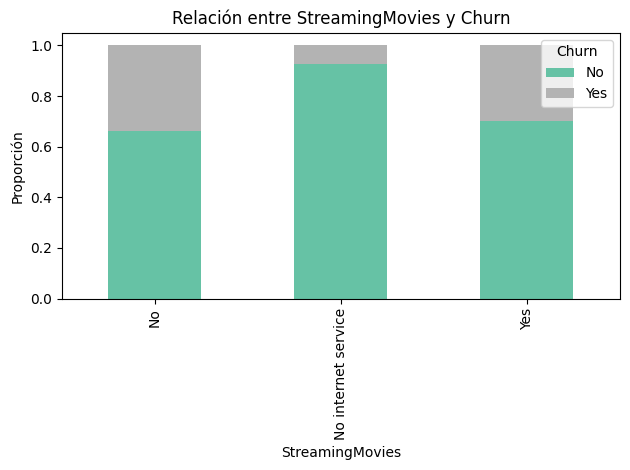

In [ ]:
# Tabla de contingencia
tabla10 = pd.crosstab(df['StreamingMovies'], df['Churn'])
print(tabla10)
print('\n \n')

# Gráfico de barras
tabla_norm10= tabla10.div(tabla10.sum(1), axis=0)

tabla_norm10.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre StreamingMovies y Churn')
plt.ylabel('Proporción')
plt.xlabel('StreamingMovies')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'Contract' y 'Churn'

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

 



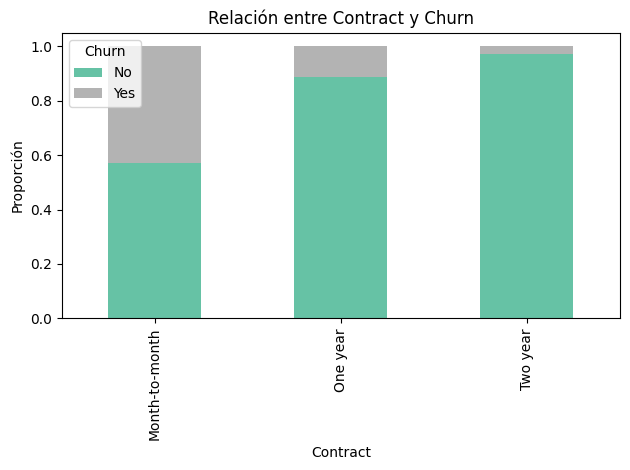

In [ ]:
# Tabla de contingencia
tabla11 = pd.crosstab(df['Contract'], df['Churn'])
print(tabla11)
print('\n \n')

# Gráfico de barras
tabla_norm11= tabla11.div(tabla11.sum(1), axis=0)

tabla_norm11.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre Contract y Churn')
plt.ylabel('Proporción')
plt.xlabel('Contract')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'PaperlessBilling' y 'Churn'

Churn               No   Yes
PaperlessBilling            
No                2403   469
Yes               2771  1400

 



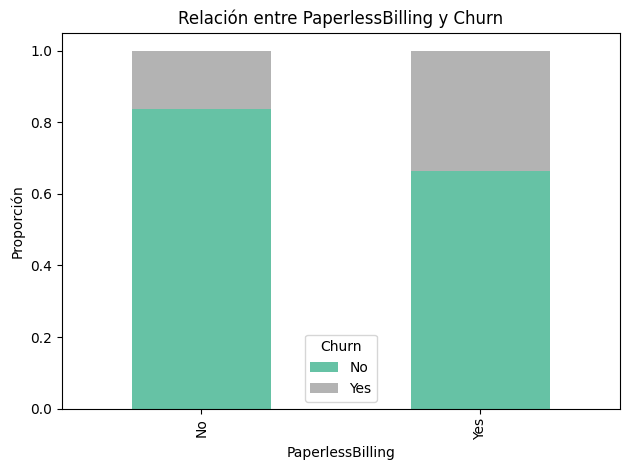

In [ ]:
# Tabla de contingencia
tabla12 = pd.crosstab(df['PaperlessBilling'], df['Churn'])
print(tabla12)
print('\n \n')

# Gráfico de barras
tabla_norm12= tabla12.div(tabla12.sum(1), axis=0)

tabla_norm12.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre PaperlessBilling y Churn')
plt.ylabel('Proporción')
plt.xlabel('PaperlessBilling')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Relación 'PaymentMethod' y 'Churn'

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

 



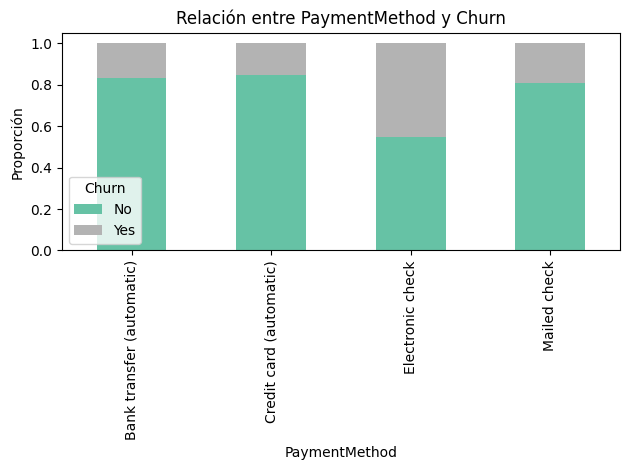

In [ ]:
# Tabla de contingencia
tabla13 = pd.crosstab(df['PaymentMethod'], df['Churn'])
print(tabla13)
print('\n \n')

# Gráfico de barras
tabla_norm13= tabla13.div(tabla13.sum(1), axis=0)

tabla_norm13.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Relación entre PaymentMethod y Churn')
plt.ylabel('Proporción')
plt.xlabel('PaymentMethod')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

Como se puede observar, para todos estos casos donde hay relación con la variable objetivo 'Churn'  (con una probabilidad menor a 0.05), hay cierta inclinación más por un valor de 'Churn' que por otro. Con lo cual, lo comprobamos no solamente con el cálculo del estimador y de la probabilidad, sino visualmente también se ve que los valores tienen más inclinación por NO permanecer en la compañia que por SI, en la mayoría de los casos.

Si tomamos algunos casos puntuales como 'TechSupport' (soporte técnico), 'InternetService' (servicio de internet) y 'PaymentMethod' (método de pago), podemos ver que para soporte técnico hay relación con la pérdida del cliente (si se quedan o se van), donde la mayoría de los clientes se fueron por no contar con soporte técnico. Entonces acá la empresa telefónica le sería útil saber que los mayores clientes se van por no contar con este servicio.

Con respecto a los métodos de pago (tambien tiene relacion con la perdida de clientes), si bien vemos en la tabla de contingencia que para la mayoría de los métodos de pago los clientes no permanecen en la telefonía, hay uno de los métodos por el cual las personas deciden quedarse y es el cheque de pago electrónico. Tal vez podriamos decir que las personas se sienten más cómodos con esta forma de pago por su practicidad y tener más control del mismo ( a diferencia de un débito automático donde no tenemos control del mismo y suele generar inconvenientes en el pago).

Por último, el servicio de internet visualizamos que se relaciona con la pérdida de los clientes, donde la mayoría decide no permanecer en la telefonía pero podemos destacar que gran parte de los clientes que si se quedan en la empresa son aquellos que tienen conexión de fibra óptica.

In [ ]:
print(tabla8)
print('\n \n')
print(tabla13)
print('\n \n')
print(tabla)

Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310

 

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

 

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
